In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

train_transaction = pd.read_csv('../data/raw/train_transaction.csv')
train_identity = pd.read_csv('../data/raw/train_identity.csv')

In [ ]:
print("\nSample Columns:")
print(list(train_transaction.columns[:]))
#print(train_transaction.dtypes.to_string())
train_transaction.head(3)


Sample Columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79',

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(list(train_identity.columns[:]))
#print(train_identity.dtypes.to_string())
train_identity.head(3)

['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


In [2]:
# Keep all transactions; fill missing identity details with NaN.
train_dt = pd.merge(train_transaction, train_identity, on='TransactionID', how='left') 
      
# Remove the original dataframes to free up RAM space
del train_transaction, train_identity   

train_dt.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
train_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [ ]:
# Class Distribution in the Target Variable 'isFraud'
target_distribution = train_dt['isFraud'].value_counts()
target_ratio        = train_dt['isFraud'].value_counts(normalize=True) * 100

print('=== Target Variable Distribution ===')
for label_val in [0, 1]:
    label_text = 'Normal (0)' if label_val == 0 else 'Fraud (1)'
    print(f'  {label_text}: {target_distribution[label_val]:6,} samples ({target_ratio[label_val]:.2f}%)')

imbalance_ratio = target_distribution[0] / target_distribution[1]
print(f'\nImbalance ratio: {imbalance_ratio:.0f}:1 (Normal:Fraud)')

=== Target Variable Distribution ===
  Normal (0): 569,877 samples (96.50%)
  Fraud (1): 20,663 samples (3.50%)

Imbalance ratio: 28:1 (Normal:Fraud)


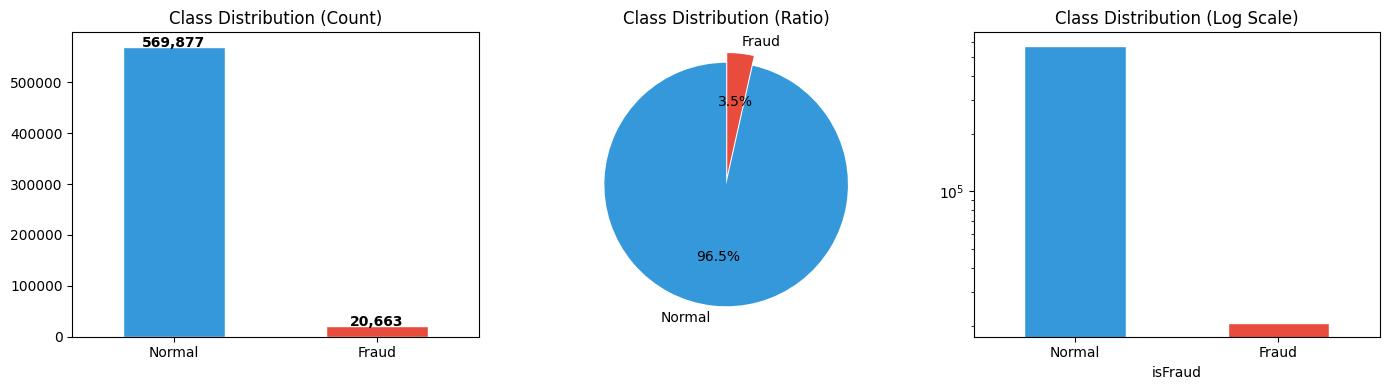

In [ ]:
# Target Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bar chart
target_distribution.plot(kind='bar', ax=axes[0],
                   color=['#3498db', '#e74c3c'], edgecolor='white', rot=0)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Normal', 'Fraud'])
for i, v in enumerate(target_distribution.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_distribution.values,
            labels=['Normal', 'Fraud'],
            colors=['#3498db', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=[0, 0.08])
axes[1].set_title('Class Distribution (Ratio)')

# Log scale — To better visualize the minority class
target_distribution.plot(kind='bar', ax=axes[2],
                   color=['#3498db', '#e74c3c'], edgecolor='white', rot=0)
axes[2].set_yscale('log')
axes[2].set_title('Class Distribution (Log Scale)')
axes[2].set_xticklabels(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()

In [3]:
numerical_cols = train_dt.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numerical   : {numerical_cols}')

object_cols = train_dt.select_dtypes(include=['object']).columns.tolist()
print(f'Object      : {object_cols}')

categorical_cols = train_dt.select_dtypes(include=['category']).columns.tolist()
print(f'Category    : {categorical_cols}')

boolean_cols = train_dt.select_dtypes(include=['bool']).columns.tolist()
print(f'Boolean     : {boolean_cols}')

non_numeric_cols = train_dt.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nNon-numeric features: {non_numeric_cols}')

Numerical   : ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V

In [ ]:
categorical_threshold = 20  
total_rows = len(train_dt)

max_display_limit = 5
current_display_count = 0

print("INSPECTING NUMERICAL COLUMNS FOR SPECIAL CASES...\n")

for col in numerical_cols:
    unique_count = train_dt[col].nunique()

    samples = train_dt[col].dropna().unique()[:5] 
    matched = False 

    if unique_count == 2:
        print(f"[BINARY/FLAG]  {col:<15} | Unique Count: {unique_count:<5} | Samples: {samples}")
        matched = True

    elif 2 < unique_count <= categorical_threshold:
        print(f"[CATEGORICAL]  {col:<15} | Unique Count: {unique_count:<5} | Samples: {samples}")
        matched = True

    elif unique_count > (total_rows * 0.9): 
        print(f"[ID/INDEX]     {col:<15} | Unique Count: {unique_count:<5} | Samples: {samples}")
        matched = True

    if matched and max_display_limit is not None:
        current_display_count += 1
        if current_display_count >= max_display_limit:
            print("-" * 75)
            print(f"Output limited to {max_display_limit} features for readability.")
            print("TIP: Set 'max_display_limit = None' in the code to view all columns.")
            break

INSPECTING NUMERICAL COLUMNS FOR SPECIAL CASES...

[ID/INDEX]     TransactionID   | Unique Count: 590540 | Samples: [2987000 2987001 2987002 2987003 2987004]
[BINARY/FLAG]  isFraud         | Unique Count: 2     | Samples: [0 1]
[ID/INDEX]     TransactionDT   | Unique Count: 573349 | Samples: [86400 86401 86469 86499 86506]
[BINARY/FLAG]  V1              | Unique Count: 2     | Samples: [1. 0.]
[CATEGORICAL]  V2              | Unique Count: 9     | Samples: [1. 2. 3. 0. 4.]
---------------------------------------------------------------------------
Output limited to 5 features for readability.
TIP: Set 'max_display_limit = None' in the code to view all columns.


In [6]:
train_dt.describe(include='object').T

,count,unique,top,freq
ProductCD,590540,5,W,439670
card4,588963,4,visa,384767
card6,588969,4,debit,439938
P_emaildomain,496084,59,gmail.com,228355
R_emaildomain,137291,60,gmail.com,57147
M1,319440,2,T,319415
M2,319440,2,T,285468
M3,319440,2,T,251731
M4,309096,3,M0,196405
M5,240058,2,F,132491


In [5]:
display(train_dt[['M4','M5','M6','id_12', 'id_15', 'id_16','id_27','id_28','id_29','id_23','DeviceType','id_34','id_36','id_37']].sample(5))

,M4,M5,M6,id_12,id_15,id_16,id_27,id_28,id_29,id_23,DeviceType,id_34,id_36,id_37
395713,M2,NaN,NaN,NotFound,Unknown,NaN,NaN,New,NotFound,NaN,mobile,NaN,F,F
541400,NaN,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316030,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252618,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155875,NaN,NaN,NaN,NotFound,New,NotFound,NaN,New,NotFound,NaN,mobile,match_status:2,F,T


In [7]:
print('Unique Value Ratio (unique / total):')
unique_oran = (train_dt.nunique() / len(train_dt)).sort_values()
#print(unique_oran.round(4).to_string())

sabit = unique_oran[unique_oran < 0.01]
if len(sabit) > 0:
    print(f'\nNear-constant columns (<1% unique): {list(sabit.index)}')
else:
    print('\n✓ No constant columns found.')

Unique Value Ratio (unique / total):

Near-constant columns (<1% unique): ['M1', 'M2', 'isFraud', 'DeviceType', 'M5', 'M6', 'M3', 'V305', 'M9', 'V1', 'M8', 'M7', 'V14', 'id_12', 'V65', 'V41', 'id_38', 'V107', 'id_16', 'V88', 'id_29', 'id_35', 'id_27', 'id_28', 'id_36', 'id_37', 'M4', 'id_23', 'V68', 'id_15', 'V89', 'V94', 'V35', 'V119', 'V28', 'card6', 'V27', 'V12', 'V117', 'id_34', 'id_32', 'V118', 'V122', 'V121', 'V120', 'card4', 'V75', 'V241', 'ProductCD', 'V10', 'V69', 'V141', 'V11', 'V29', 'V53', 'V240', 'V21', 'V50', 'V48', 'V90', 'V36', 'V49', 'V25', 'V13', 'V54', 'V46', 'V51', 'V57', 'V61', 'V33', 'V91', 'V70', 'V71', 'V76', 'V5', 'V116', 'V114', 'V115', 'V4', 'V108', 'V15', 'V19', 'V93', 'V31', 'V66', 'V63', 'V173', 'V110', 'V92', 'V83', 'V84', 'V85', 'V73', 'V109', 'V82', 'V79', 'V30', 'V64', 'V194', 'V43', 'V67', 'V286', 'V52', 'V74', 'V42', 'V47', 'V9', 'V22', 'V2', 'V174', 'V8', 'V260', 'V113', 'V112', 'V142', 'V3', 'V7', 'V111', 'V6', 'V72', 'V58', 'V288', 'V62', 'V300', 

In [6]:
standard_mapping = {
    'T': 1, 'F': 0,
    'Found': 1, 'NotFound': 0,
    'New': 0,            
    'mobile': 1, 'desktop': 0 
}

object_columns = train_dt.select_dtypes(include=['object']).columns

hidden_missing_values = ['Unknown', 'unknown', 'unkown', 'UNKNOWN', 'None', 'none']
train_dt[object_columns] = train_dt[object_columns].replace(hidden_missing_values, np.nan)

for col in object_columns:
    unique_values = train_dt[col].dropna().unique()

    if len(unique_values) == 2:
        val1, val2 = unique_values[0], unique_values[1]

        if val1 in standard_mapping and val2 in standard_mapping:
            mapping = {
                val1: standard_mapping[val1], 
                val2: standard_mapping[val2]
            }

        else:
            mapping = {val1: 1, val2: 0} 


        train_dt[col] = train_dt[col].map(mapping).astype('Int8')
        
        print(f"Log: '{col}' converted. Mapping: {mapping}, NaNs preserved.")

Log: 'M1' converted. Mapping: {'T': 1, 'F': 0}, NaNs preserved.
Log: 'M2' converted. Mapping: {'T': 1, 'F': 0}, NaNs preserved.
Log: 'M3' converted. Mapping: {'T': 1, 'F': 0}, NaNs preserved.
Log: 'M5' converted. Mapping: {'F': 0, 'T': 1}, NaNs preserved.
Log: 'M6' converted. Mapping: {'T': 1, 'F': 0}, NaNs preserved.
Log: 'M7' converted. Mapping: {'F': 0, 'T': 1}, NaNs preserved.
Log: 'M8' converted. Mapping: {'F': 0, 'T': 1}, NaNs preserved.
Log: 'M9' converted. Mapping: {'F': 0, 'T': 1}, NaNs preserved.
Log: 'id_12' converted. Mapping: {'NotFound': 0, 'Found': 1}, NaNs preserved.
Log: 'id_15' converted. Mapping: {'New': 0, 'Found': 1}, NaNs preserved.
Log: 'id_16' converted. Mapping: {'NotFound': 0, 'Found': 1}, NaNs preserved.
Log: 'id_27' converted. Mapping: {'Found': 1, 'NotFound': 0}, NaNs preserved.
Log: 'id_28' converted. Mapping: {'New': 0, 'Found': 1}, NaNs preserved.
Log: 'id_29' converted. Mapping: {'NotFound': 0, 'Found': 1}, NaNs preserved.
Log: 'id_35' converted. Mappin

In [7]:
train_dt.describe(include='object').T

,count,unique,top,freq
ProductCD,590540,5,W,439670
card4,588963,4,visa,384767
card6,588969,4,debit,439938
P_emaildomain,496084,59,gmail.com,228355
R_emaildomain,137291,60,gmail.com,57147
M4,309096,3,M0,196405
id_23,5169,3,IP_PROXY:TRANSPARENT,3489
id_30,77565,75,Windows 10,21155
id_31,140282,130,chrome 63.0,22000
id_33,73289,260,1920x1080,16874


In [8]:
# === Missing Data Report ===
missing_count = train_dt.isnull().sum()
missing_pct = train_dt.isnull().mean() * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2),
    'Data Type': train_dt.dtypes.astype(str)
})

# Filter only columns that have at least one missing value and sort by percentage
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Data Analysis Report ===')
if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    # To view the FULL list, uncomment the line below:
    # print(missing_df.to_string()) 
    print(missing_df.head(15))

=== Missing Data Analysis Report ===
       Missing Count  Missing % Data Type
id_24         585793      99.20   float64
id_07         585385      99.13   float64
id_26         585377      99.13   float64
id_21         585381      99.13   float64
id_08         585385      99.13   float64
id_25         585408      99.13   float64
id_23         585371      99.12    object
id_22         585371      99.12   float64
id_27         585371      99.12      Int8
dist2         552913      93.63   float64
D7            551623      93.41   float64
id_18         545427      92.36   float64
D13           528588      89.51   float64
D14           528353      89.47   float64
D12           525823      89.04   float64


In [9]:
train_dt['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

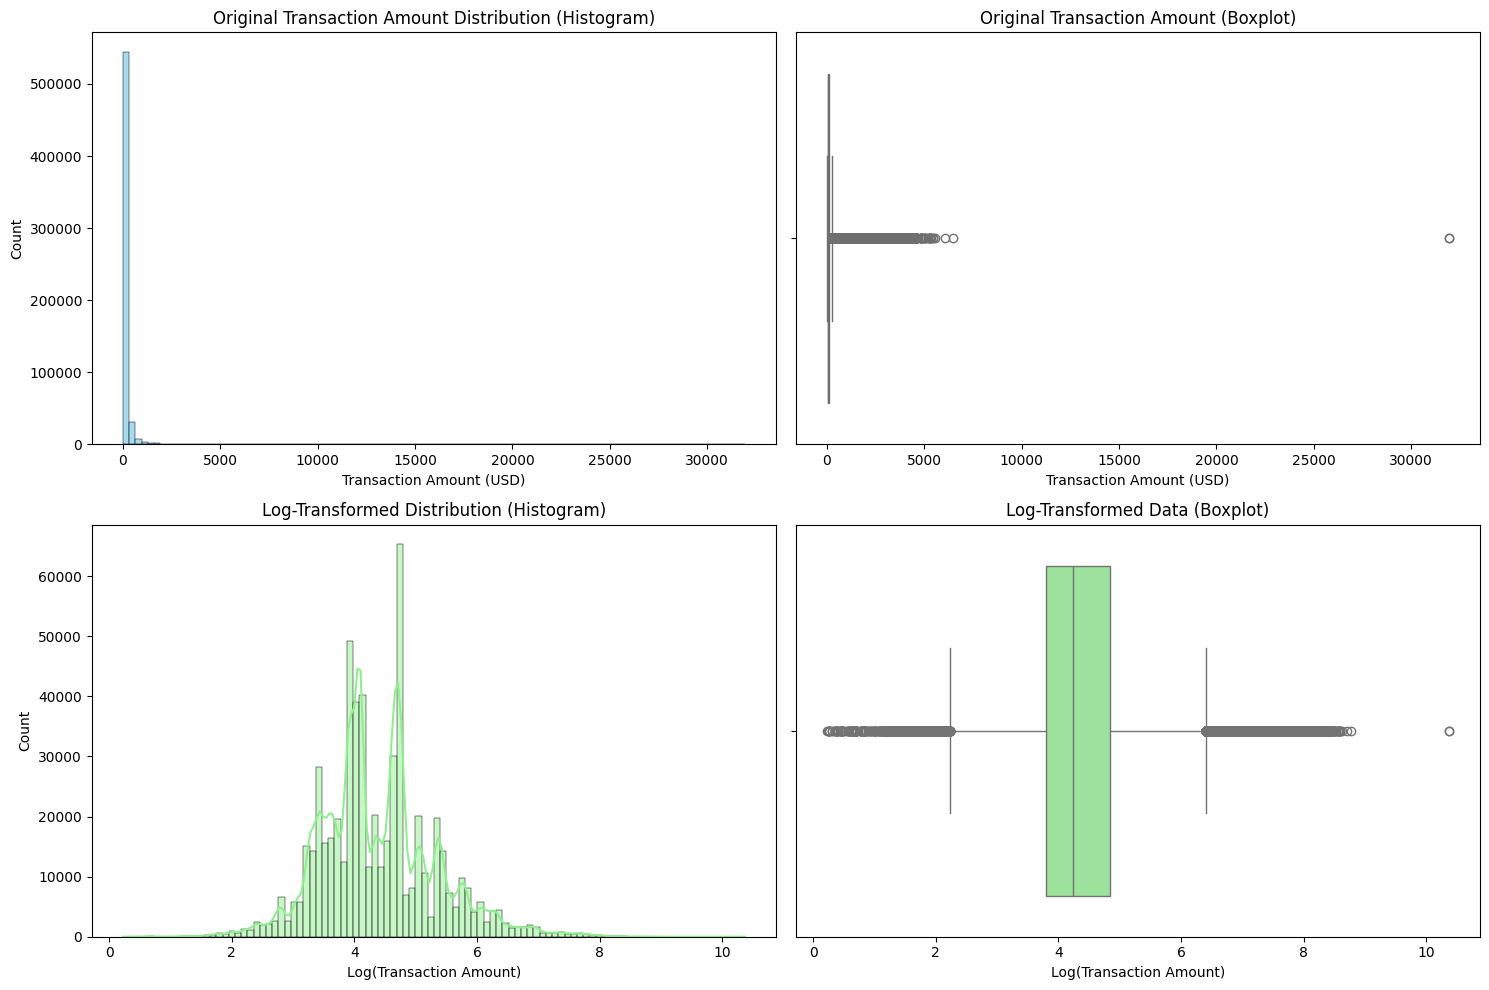

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- ROW 1: ORIGINAL DATA ---
# Top Left: Original Data Histogram
sns.histplot(train_dt['TransactionAmt'], bins=100, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Original Transaction Amount Distribution (Histogram)')
axes[0, 0].set_xlabel('Transaction Amount (USD)')

# Top Right: Original Data Boxplot
sns.boxplot(x=train_dt['TransactionAmt'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Original Transaction Amount (Boxplot)')
axes[0, 1].set_xlabel('Transaction Amount (USD)')

# --- ROW 2: LOG-TRANSFORMED DATA ---
# Note: np.log1p() calculates log(1+x). It prevents errors if there are 0 values.

# Bottom Left: Log-Transformed Data Histogram
sns.histplot(np.log1p(train_dt['TransactionAmt']), bins=100, ax=axes[1, 0], color='lightgreen', kde=True)
axes[1, 0].set_title('Log-Transformed Distribution (Histogram)')
axes[1, 0].set_xlabel('Log(Transaction Amount)')

# Bottom Right: Log-Transformed Data Boxplot
sns.boxplot(x=np.log1p(train_dt['TransactionAmt']), ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Log-Transformed Data (Boxplot)')
axes[1, 1].set_xlabel('Log(Transaction Amount)')

# Prevent overlapping charts and display
plt.tight_layout()
plt.show()

In [10]:
train_dt.to_csv('../data/processed/train_data.csv', index=False)